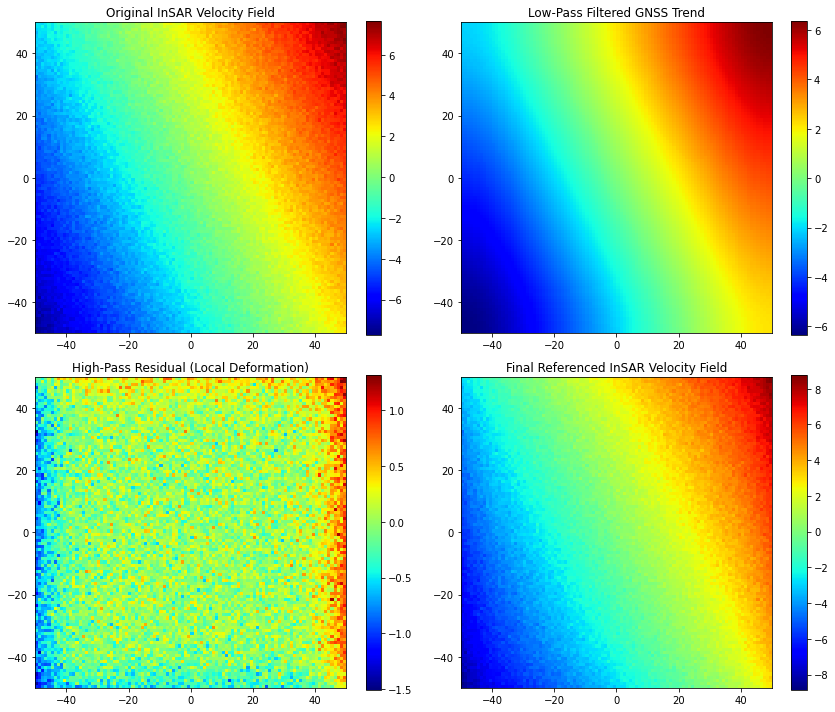

In [1]:
import numpy as np
import scipy.ndimage as ndimage
import matplotlib.pyplot as plt

# Generate synthetic InSAR velocity field (random noise + large-scale trend)
np.random.seed(42)
x = np.linspace(-50, 50, 100)
y = np.linspace(-50, 50, 100)
X, Y = np.meshgrid(x, y)

# Large-scale tectonic trend (low-frequency signal)
V_GNSS = 0.1 * X + 0.05 * Y  

# Local deformation signal (high-frequency noise)
V_InSAR = V_GNSS + np.random.normal(0, 0.2, size=X.shape)

# Apply a Gaussian low-pass filter to extract the large-scale trend
sigma = 10  # Controls smoothing level
V_LowPass = ndimage.gaussian_filter(V_InSAR, sigma=sigma)

# Compute high-pass residuals (local deformation)
V_HighPass = V_InSAR - V_LowPass

# Final referenced velocity field (adding back GNSS trend)
V_Referenced = V_HighPass + V_GNSS

# Plot results
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

ax = axes[0, 0]
im = ax.imshow(V_InSAR, extent=[-50, 50, -50, 50], cmap="jet", origin="lower")
ax.set_title("Original InSAR Velocity Field")
fig.colorbar(im, ax=ax)

ax = axes[0, 1]
im = ax.imshow(V_LowPass, extent=[-50, 50, -50, 50], cmap="jet", origin="lower")
ax.set_title("Low-Pass Filtered GNSS Trend")
fig.colorbar(im, ax=ax)

ax = axes[1, 0]
im = ax.imshow(V_HighPass, extent=[-50, 50, -50, 50], cmap="jet", origin="lower")
ax.set_title("High-Pass Residual (Local Deformation)")
fig.colorbar(im, ax=ax)

ax = axes[1, 1]
im = ax.imshow(V_Referenced, extent=[-50, 50, -50, 50], cmap="jet", origin="lower")
ax.set_title("Final Referenced InSAR Velocity Field")
fig.colorbar(im, ax=ax)

plt.tight_layout()
plt.show()


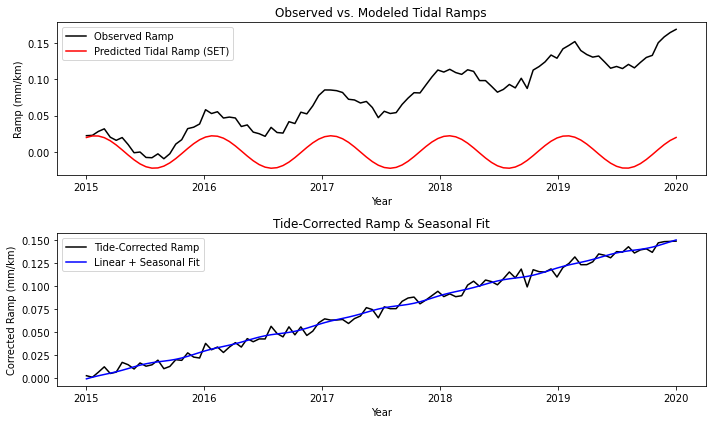

Estimated Ramp Rate (a_dot): 0.0302 mm/km/yr
RMS Error (σ): 0.0044 mm/km


In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# Simulated dataset: Observed and predicted tidal ramps
np.random.seed(42)
time = np.linspace(2015, 2020, 100)  # Time in years
observed_ramp = 0.03 * (time - 2015) + 0.02 * np.cos(2 * np.pi * time) + 0.01 * np.sin(2 * np.pi * time) + np.random.normal(0, 0.005, len(time))
predicted_tide_ramp = 0.02 * np.cos(2 * np.pi * time) + 0.01 * np.sin(2 * np.pi * time)  # Modelled SET effect

# Compute tide-corrected ramp
tide_corrected_ramp = observed_ramp - predicted_tide_ramp

# Define the linear + seasonal model
def ramp_model(t, a0, a_dot, ac, as_, a2c, a2s):
    return a0 + a_dot * (t - 2015) + ac * np.cos(2 * np.pi * t) + as_ * np.sin(2 * np.pi * t) + a2c * np.cos(4 * np.pi * t) + a2s * np.sin(4 * np.pi * t)

# Fit the model to tide-corrected ramps
params, covariance = curve_fit(ramp_model, time, tide_corrected_ramp)
a0, a_dot, ac, as_, a2c, a2s = params

# Compute fitted values
fitted_ramp = ramp_model(time, *params)

# Compute RMS error (σ)
residuals = tide_corrected_ramp - fitted_ramp
sigma = np.sqrt(np.mean(residuals**2))

# Plot results
plt.figure(figsize=(10, 6))

plt.subplot(2,1,1)
plt.plot(time, observed_ramp, label="Observed Ramp", color='black')
plt.plot(time, predicted_tide_ramp, label="Predicted Tidal Ramp (SET)", color='red')
plt.xlabel("Year")
plt.ylabel("Ramp (mm/km)")
plt.title("Observed vs. Modeled Tidal Ramps")
plt.legend()

plt.subplot(2,1,2)
plt.plot(time, tide_corrected_ramp, label="Tide-Corrected Ramp", color='black')
plt.plot(time, fitted_ramp, label="Linear + Seasonal Fit", color='blue')
plt.xlabel("Year")
plt.ylabel("Corrected Ramp (mm/km)")
plt.title("Tide-Corrected Ramp & Seasonal Fit")
plt.legend()

plt.tight_layout()
plt.show()

print(f"Estimated Ramp Rate (a_dot): {a_dot:.4f} mm/km/yr")
print(f"RMS Error (σ): {sigma:.4f} mm/km")


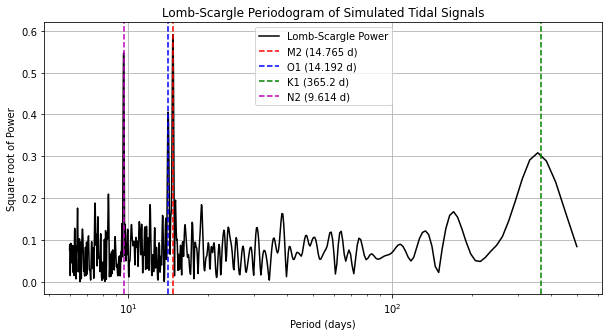

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.timeseries import LombScargle

# Simulate a time series with multiple periodic signals (M2, O1, K1 tides)
np.random.seed(42)
time = np.sort(np.random.uniform(0, 1000, 300))  # Simulated observation times over ~3 years
M2_period = 14.765  # Major lunar tide period
O1_period = 14.192  # Diurnal tide
K1_period = 365.2   # Solar tide (annual)
N2_period = 9.614   # Semi-diurnal lunar tide

# Generate synthetic tidal signal
M2_signal = np.sin(2 * np.pi * time / M2_period)
O1_signal = np.sin(2 * np.pi * time / O1_period)
K1_signal = np.sin(2 * np.pi * time / K1_period)
N2_signal = np.sin(2 * np.pi * time / N2_period)

# Sum tidal components and add noise
signal = 0.5 * M2_signal + 0.3 * O1_signal + 0.2 * K1_signal + 0.4 * N2_signal
signal += 0.2 * np.random.randn(len(time))  # Add random noise

# Compute Lomb-Scargle periodogram
frequency, power = LombScargle(time, signal).autopower(minimum_frequency=1/500, maximum_frequency=1/6)

# Convert frequency to period
period = 1 / frequency

# Plot periodogram
plt.figure(figsize=(10, 5))
plt.plot(period, np.sqrt(power), 'k-', label="Lomb-Scargle Power")
plt.axvline(M2_period, color='r', linestyle='--', label="M2 (14.765 d)")
plt.axvline(O1_period, color='b', linestyle='--', label="O1 (14.192 d)")
plt.axvline(K1_period, color='g', linestyle='--', label="K1 (365.2 d)")
plt.axvline(N2_period, color='m', linestyle='--', label="N2 (9.614 d)")

plt.xscale("log")  # Log scale for better visualization
plt.xlabel("Period (days)")
plt.ylabel("Square root of Power")
plt.title("Lomb-Scargle Periodogram of Simulated Tidal Signals")
plt.legend()
plt.grid(True)
plt.show()


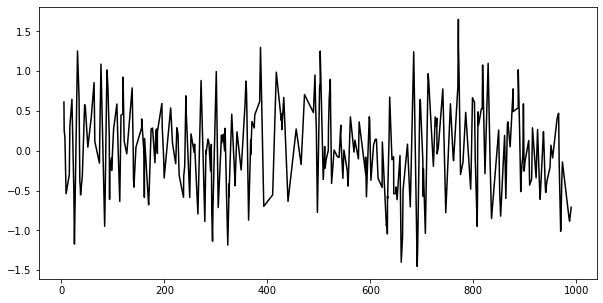

In [8]:
plt.figure(figsize=(10, 5))
plt.plot(time, signal, 'k-')

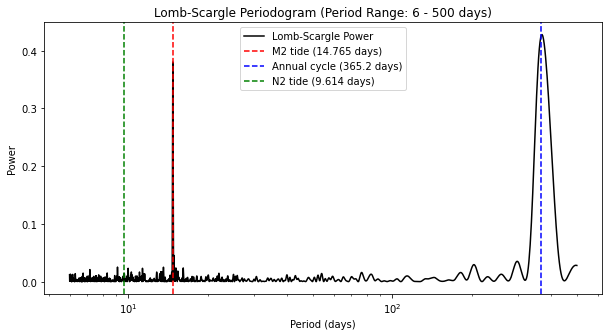

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.timeseries import LombScargle

# Simulated time series data
np.random.seed(42)
time = np.sort(np.random.uniform(0, 2000, 500))  # Simulated observation times over ~5 years
signal = np.sin(2 * np.pi * time / 14.765) + np.sin(2 * np.pi * time / 365.2)  # M2 + annual signal
signal += 0.5 * np.random.randn(len(time))  # Add some noise

# Define period range (e.g., 6 to 500 days)
min_period = 6   # Shortest period in days
max_period = 500 # Longest period in days
frequencies = np.linspace(1/max_period, 1/min_period, 10000)  # Convert periods to frequencies

# Compute Lomb-Scargle periodogram
power = LombScargle(time, signal).power(frequencies)

# Convert frequencies to periods for plotting
periods = 1 / frequencies

# Plot periodogram
plt.figure(figsize=(10, 5))
plt.plot(periods, power, 'k-', label="Lomb-Scargle Power")
plt.xlabel("Period (days)")
plt.ylabel("Power")
plt.title(f"Lomb-Scargle Periodogram (Period Range: {min_period} - {max_period} days)")
plt.axvline(14.765, color='r', linestyle='--', label="M2 tide (14.765 days)")
plt.axvline(365.2, color='b', linestyle='--', label="Annual cycle (365.2 days)")
plt.axvline(9.614, color='g', linestyle='--', label="N2 tide (9.614 days)")
plt.legend()
plt.xscale('log')  # Log scale for better visualization
plt.show()


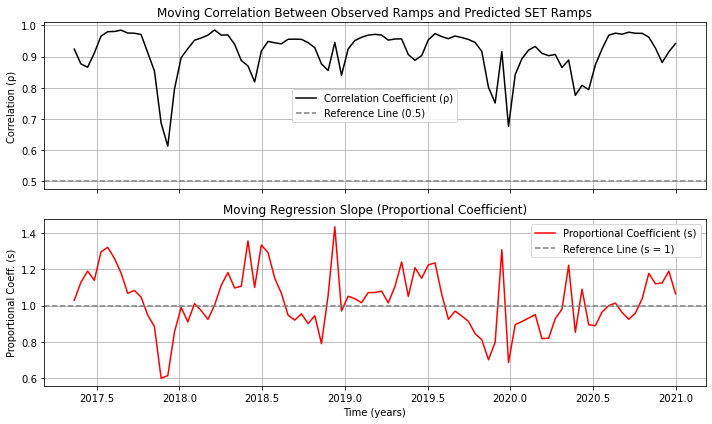

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import linregress

# Simulated time series data (replace with real data)
np.random.seed(42)
time = np.linspace(2017, 2021, 100)  # Time from 2017 to 2021
observed_ramp = 0.1 * np.sin(2 * np.pi * time) + 0.02 * np.random.randn(len(time))  # Simulated observed ramp
predicted_ramp = 0.1 * np.sin(2 * np.pi * time)  # Simulated predicted SET ramp

# Window size for moving correlation and proportional coefficient (adjustable)
window_size = 10

# Initialize arrays for storing results
correlation_coeffs = np.zeros(len(time) - window_size + 1)
proportional_coeffs = np.zeros(len(time) - window_size + 1)

# Compute moving correlation and proportional coefficient
for i in range(len(time) - window_size + 1):
    window_obs = observed_ramp[i:i + window_size]
    window_pred = predicted_ramp[i:i + window_size]
    
    # Compute correlation coefficient
    correlation_coeffs[i] = np.corrcoef(window_obs, window_pred)[0, 1]
    
    # Compute proportional coefficient (slope from linear regression)
    slope, _, _, _, _ = linregress(window_pred, window_obs)
    proportional_coeffs[i] = slope

# Define time for correlation plots (centered moving window)
time_corr = time[window_size - 1:]

# Plot results
fig, axs = plt.subplots(2, 1, figsize=(10, 6), sharex=True)

# Correlation coefficient plot (ρ)
axs[0].plot(time_corr, correlation_coeffs, 'k-', label="Correlation Coefficient (ρ)")
axs[0].axhline(y=0.5, color='gray', linestyle="--", label="Reference Line (0.5)")
axs[0].set_ylabel("Correlation (ρ)")
axs[0].set_title("Moving Correlation Between Observed Ramps and Predicted SET Ramps")
axs[0].legend()
axs[0].grid()

# Proportional coefficient plot (s)
axs[1].plot(time_corr, proportional_coeffs, 'r-', label="Proportional Coefficient (s)")
axs[1].axhline(y=1, color='gray', linestyle="--", label="Reference Line (s = 1)")
axs[1].set_xlabel("Time (years)")
axs[1].set_ylabel("Proportional Coeff. (s)")
axs[1].set_title("Moving Regression Slope (Proportional Coefficient)")
axs[1].legend()
axs[1].grid()

plt.tight_layout()
plt.show()


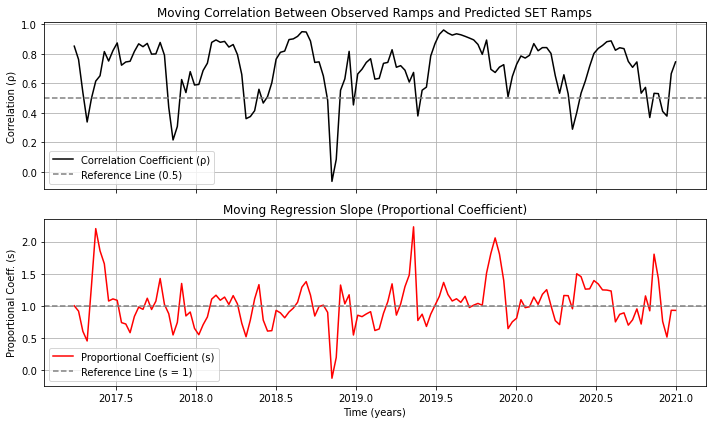

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import linregress

# Simulated time series (replace with real InSAR and SET ramp data)
np.random.seed(42)
time = np.linspace(2017, 2021, 150)  # Time from 2017 to 2021
observed_ramp = 0.1 * np.sin(2 * np.pi * time) + 0.03 * np.random.randn(len(time))  # Simulated observed ramp
predicted_ramp = 0.1 * np.sin(2 * np.pi * time)  # Simulated predicted SET ramp

# Moving window size (adjust as needed)
window_size = 10

# Initialize arrays for correlation and proportional coefficient
correlation_coeffs = np.zeros(len(time) - window_size + 1)
proportional_coeffs = np.zeros(len(time) - window_size + 1)

# Compute moving correlation and proportional coefficient
for i in range(len(time) - window_size + 1):
    window_obs = observed_ramp[i:i + window_size]
    window_pred = predicted_ramp[i:i + window_size]
    
    # Compute correlation coefficient
    correlation_coeffs[i] = np.corrcoef(window_obs, window_pred)[0, 1]
    
    # Compute proportional coefficient (slope from regression)
    slope, _, _, _, _ = linregress(window_pred, window_obs)
    proportional_coeffs[i] = slope

# Define time for correlation plots
time_corr = time[window_size - 1:]

# Plot correlation and proportional coefficient
fig, axs = plt.subplots(2, 1, figsize=(10, 6), sharex=True)

# Correlation coefficient plot
axs[0].plot(time_corr, correlation_coeffs, 'k-', label="Correlation Coefficient (ρ)")
axs[0].axhline(y=0.5, color='gray', linestyle="--", label="Reference Line (0.5)")
axs[0].set_ylabel("Correlation (ρ)")
axs[0].set_title("Moving Correlation Between Observed Ramps and Predicted SET Ramps")
axs[0].legend()
axs[0].grid()

# Proportional coefficient plot
axs[1].plot(time_corr, proportional_coeffs, 'r-', label="Proportional Coefficient (s)")
axs[1].axhline(y=1, color='gray', linestyle="--", label="Reference Line (s = 1)")
axs[1].set_xlabel("Time (years)")
axs[1].set_ylabel("Proportional Coeff. (s)")
axs[1].set_title("Moving Regression Slope (Proportional Coefficient)")
axs[1].legend()
axs[1].grid()

plt.tight_layout()
plt.show()


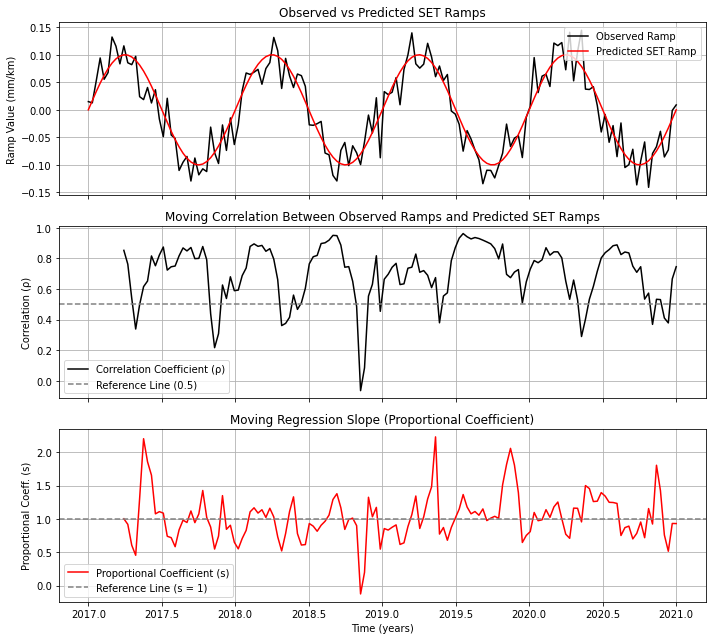

In [14]:
# Re-import necessary libraries since execution state was reset
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import linregress

# Simulated time series (replace with real InSAR and SET ramp data)
np.random.seed(42)
time = np.linspace(2017, 2021, 150)  # Time from 2017 to 2021
observed_ramp = 0.1 * np.sin(2 * np.pi * time) + 0.03 * np.random.randn(len(time))  # Simulated observed ramp
predicted_ramp = 0.1 * np.sin(2 * np.pi * time)  # Simulated predicted SET ramp

# Moving window size (adjust as needed)
window_size = 10

# Initialize arrays for correlation and proportional coefficient
correlation_coeffs = np.zeros(len(time) - window_size + 1)
proportional_coeffs = np.zeros(len(time) - window_size + 1)

# Compute moving correlation and proportional coefficient
for i in range(len(time) - window_size + 1):
    window_obs = observed_ramp[i:i + window_size]
    window_pred = predicted_ramp[i:i + window_size]
    
    # Compute correlation coefficient
    correlation_coeffs[i] = np.corrcoef(window_obs, window_pred)[0, 1]
    
    # Compute proportional coefficient (slope from regression)
    slope, _, _, _, _ = linregress(window_pred, window_obs)
    proportional_coeffs[i] = slope

# Define time for correlation plots
time_corr = time[window_size - 1:]

# Plot observed and predicted ramps
fig, axs = plt.subplots(3, 1, figsize=(10, 9), sharex=True)

# Observed vs Predicted ramps
axs[0].plot(time, observed_ramp, 'k-', label="Observed Ramp")
axs[0].plot(time, predicted_ramp, 'r-', label="Predicted SET Ramp")
axs[0].set_ylabel("Ramp Value (mm/km)")
axs[0].set_title("Observed vs Predicted SET Ramps")
axs[0].legend()
axs[0].grid()

# Correlation coefficient plot
axs[1].plot(time_corr, correlation_coeffs, 'k-', label="Correlation Coefficient (ρ)")
axs[1].axhline(y=0.5, color='gray', linestyle="--", label="Reference Line (0.5)")
axs[1].set_ylabel("Correlation (ρ)")
axs[1].set_title("Moving Correlation Between Observed Ramps and Predicted SET Ramps")
axs[1].legend()
axs[1].grid()

# Proportional coefficient plot
axs[2].plot(time_corr, proportional_coeffs, 'r-', label="Proportional Coefficient (s)")
axs[2].axhline(y=1, color='gray', linestyle="--", label="Reference Line (s = 1)")
axs[2].set_xlabel("Time (years)")
axs[2].set_ylabel("Proportional Coeff. (s)")
axs[2].set_title("Moving Regression Slope (Proportional Coefficient)")
axs[2].legend()
axs[2].grid()

plt.tight_layout()
plt.show()


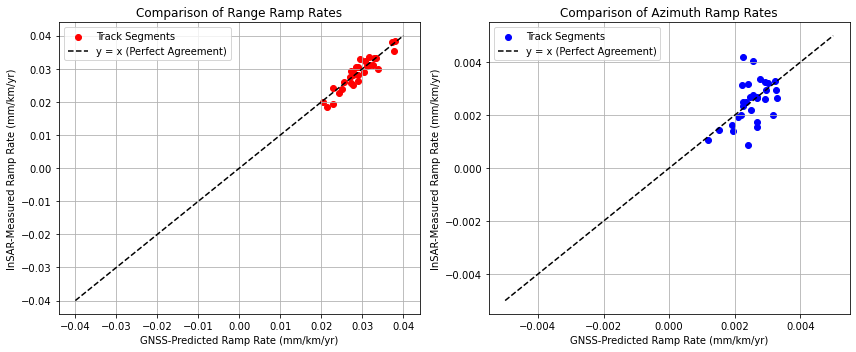

In [17]:
import numpy as np
import matplotlib.pyplot as plt

# Simulated GNSS and InSAR ramp rates (replace with actual data)
np.random.seed(42)
num_chunks = 30
gnss_ramp_range = np.random.normal(0.03, 0.005, num_chunks)  # GNSS ramp rate in range (mm/km/yr)
insar_ramp_range = gnss_ramp_range + np.random.normal(0, 0.002, num_chunks)  # InSAR estimates with noise

gnss_ramp_azimuth = np.random.normal(0.0025, 0.0005, num_chunks)  # GNSS ramp rate in azimuth
insar_ramp_azimuth = gnss_ramp_azimuth + np.random.normal(0, 0.0008, num_chunks)  # InSAR estimates with noise

# Plotting comparisons
fig, axs = plt.subplots(1, 2, figsize=(12, 5))

# Range ramp rate comparison
axs[0].scatter(gnss_ramp_range, insar_ramp_range, color='red', label="Track Segments")
axs[0].plot([-0.04, 0.04], [-0.04, 0.04], 'k--', label="y = x (Perfect Agreement)")
axs[0].set_xlabel("GNSS-Predicted Ramp Rate (mm/km/yr)")
axs[0].set_ylabel("InSAR-Measured Ramp Rate (mm/km/yr)")
axs[0].set_title("Comparison of Range Ramp Rates")
axs[0].legend()
axs[0].grid()

# Azimuth ramp rate comparison
axs[1].scatter(gnss_ramp_azimuth, insar_ramp_azimuth, color='blue', label="Track Segments")
axs[1].plot([-0.005, 0.005], [-0.005, 0.005], 'k--', label="y = x (Perfect Agreement)")
axs[1].set_xlabel("GNSS-Predicted Ramp Rate (mm/km/yr)")
axs[1].set_ylabel("InSAR-Measured Ramp Rate (mm/km/yr)")
axs[1].set_title("Comparison of Azimuth Ramp Rates")
axs[1].legend()
axs[1].grid()

plt.tight_layout()
plt.show()


GNSS Ramp Rate in Range: -0.00008 mm/km/yr
GNSS Ramp Rate in Azimuth: -0.00000 mm/km/yr


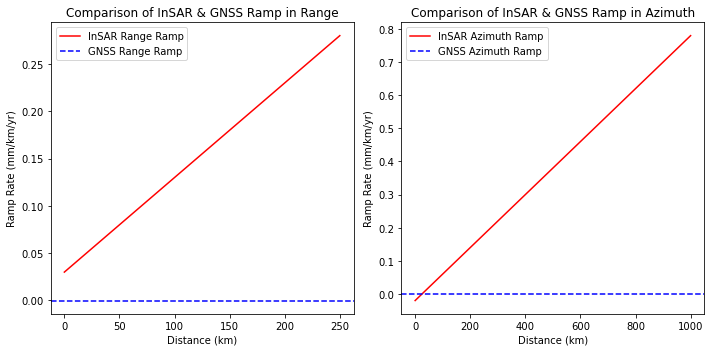

In [16]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import linregress

# Simulated GNSS velocities (in mm/yr)
gnss_x = np.linspace(0, 250, 30)  # Range distance (km)
gnss_y = np.linspace(0, 1000, 30)  # Azimuth distance (km)
gnss_velocity = 30 + 0.02 * gnss_x - 0.01 * gnss_y  # Linear velocity trend (mm/yr)

# Simulated InSAR phase ramps (mm/km)
insar_range_ramp = 0.03 + 0.001 * gnss_x  # Simulated range ramp rate
insar_azimuth_ramp = -0.02 + 0.0008 * gnss_y  # Simulated azimuth ramp rate

# Compute GNSS-based ramp rate using linear regression
slope_x, _, _, _, _ = linregress(gnss_x, gnss_velocity)
slope_y, _, _, _, _ = linregress(gnss_y, gnss_velocity)

gnss_range_ramp = slope_x / 250  # Convert mm/yr to mm/km/yr
gnss_azimuth_ramp = slope_y / 1000  # Convert mm/yr to mm/km/yr

print(f"GNSS Ramp Rate in Range: {gnss_range_ramp:.5f} mm/km/yr")
print(f"GNSS Ramp Rate in Azimuth: {gnss_azimuth_ramp:.5f} mm/km/yr")

# Plot InSAR and GNSS Ramp Rates
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.plot(gnss_x, insar_range_ramp, 'r-', label="InSAR Range Ramp")
plt.axhline(gnss_range_ramp, color='b', linestyle='--', label="GNSS Range Ramp")
plt.xlabel("Distance (km)")
plt.ylabel("Ramp Rate (mm/km/yr)")
plt.title("Comparison of InSAR & GNSS Ramp in Range")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(gnss_y, insar_azimuth_ramp, 'r-', label="InSAR Azimuth Ramp")
plt.axhline(gnss_azimuth_ramp, color='b', linestyle='--', label="GNSS Azimuth Ramp")
plt.xlabel("Distance (km)")
plt.ylabel("Ramp Rate (mm/km/yr)")
plt.title("Comparison of InSAR & GNSS Ramp in Azimuth")
plt.legend()

plt.tight_layout()
plt.show()


Fitted Parameters:
 A0 = -0.05 mm
 Ac = 2.01 mm
 As = 1.52 mm
 V_LOS = 0.51 mm/yr


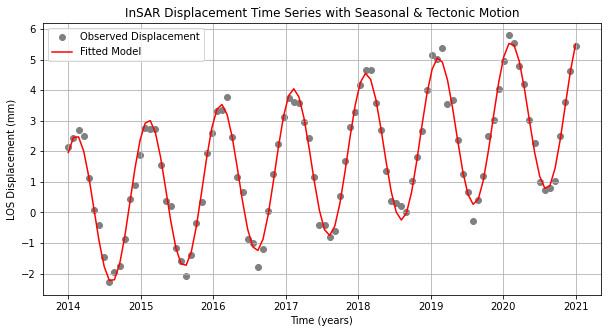

In [18]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# Simulated time-series (replace with real InSAR displacement data)
np.random.seed(42)
time_years = np.linspace(2014, 2021, 100)  # Sentinel-1 time range
displacement = (
    2.0 * np.cos(2 * np.pi * time_years)  # Seasonal variation (winter-summer)
    + 1.5 * np.sin(2 * np.pi * time_years)  # Seasonal variation (spring-autumn)
    + 0.5 * (time_years - 2014)  # Tectonic velocity
    + 0.3 * np.random.randn(len(time_years))  # Noise
)

# Define velocity model (Equation 8)
def velocity_model(t, A0, Ac, As, V_LOS):
    return A0 + Ac * np.cos(2 * np.pi * t) + As * np.sin(2 * np.pi * t) + V_LOS * (t - 2014)

# Fit model to data
popt, _ = curve_fit(velocity_model, time_years, displacement)

# Extract parameters
A0_fit, Ac_fit, As_fit, V_LOS_fit = popt
print(f"Fitted Parameters:\n A0 = {A0_fit:.2f} mm\n Ac = {Ac_fit:.2f} mm\n As = {As_fit:.2f} mm\n V_LOS = {V_LOS_fit:.2f} mm/yr")

# Plot results
plt.figure(figsize=(10, 5))
plt.scatter(time_years, displacement, color='gray', label="Observed Displacement")
plt.plot(time_years, velocity_model(time_years, *popt), 'r-', label="Fitted Model")
plt.xlabel("Time (years)")
plt.ylabel("LOS Displacement (mm)")
plt.title("InSAR Displacement Time Series with Seasonal & Tectonic Motion")
plt.legend()
plt.grid()
plt.show()


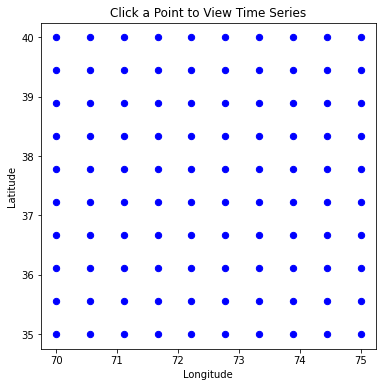

In [1]:
# Re-import necessary libraries due to execution reset
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr
import pandas as pd

# Simulated cumxr_iono dataset
time = pd.date_range(start="2025-01-01", periods=50, freq="10D")  # 50 time steps
lat = np.linspace(35, 40, 10)  # 10 latitude points
lon = np.linspace(70, 75, 10)  # 10 longitude points

# Simulated ionospheric correction data (random cumulative variation)
np.random.seed(42)
data = np.cumsum(np.random.randn(50, 10, 10), axis=0)  # Simulating ionospheric variations

# Create xarray DataArray
cumxr_iono = xr.DataArray(data, coords=[time, lat, lon], dims=["time", "lat", "lon"])

# Plot interactive map for selecting a point
fig, ax = plt.subplots(figsize=(6, 6))
sc = ax.scatter(*np.meshgrid(lon, lat), c="blue", s=40, picker=True)  # Clickable points

ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_title("Click a Point to View Time Series")

selected_point = {"lon": None, "lat": None}

def on_pick(event):
    global selected_point
    ind = event.ind[0]  # Get index of clicked point
    lon_index = ind % len(lon)
    lat_index = ind // len(lon)

    selected_point["lon"] = lon[lon_index]
    selected_point["lat"] = lat[lat_index]

    # Extract time series at selected location
    time_series = cumxr_iono.sel(lon=selected_point["lon"], lat=selected_point["lat"], method="nearest")

    # Plot time series
    plt.figure(figsize=(10, 5))
    plt.plot(time_series.time, time_series.values, marker="o", linestyle="-", label=f"Iono Correction at ({selected_point['lat']}, {selected_point['lon']})")
    plt.xlabel("Time")
    plt.ylabel("Ionospheric Correction (mm)")
    plt.title(f"Ionospheric Correction Time Series at ({selected_point['lat']:.2f}, {selected_point['lon']:.2f})")
    plt.grid(True)
    plt.legend()
    plt.xticks(rotation=45)
    plt.show()

# Connect event handler
fig.canvas.mpl_connect("pick_event", on_pick)
plt.show()


In [2]:
# Connect the pick event to the figure
fig.canvas.mpl_connect("pick_event", on_pick)

# Display the interactive map
plt.show()